In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, beta, invgamma
import arviz as az
import pymc as pm

In [2]:
np.random.seed(1)

In [3]:
# Defining the observed data.

n = 10
heads = 7

print("Number of trials:", n)
print("Number of heads:", heads)

# Creating a grid of parameter values.

theta_grid = np.linspace(0.001, 0.999, 500)

Number of trials: 10
Number of heads: 7


In [4]:
# Defining a non-conjugate prior.

prior = theta_grid

# Normalizing the prior.

prior = prior / np.trapezoid(prior, theta_grid)

# Computing the likelihood.

likelihood = binom.pmf(heads, n, theta_grid)

# Computing the unnormalized posterior.

unnormalized_posterior = prior * likelihood

# Normalizing the posterior.

posterior = unnormalized_posterior / np.trapezoid(
    unnormalized_posterior,
    theta_grid
)

# Computing the posterior mean.

posterior_mean = np.trapezoid(
    theta_grid * posterior,
    theta_grid
)

print("Posterior mean: ", posterior_mean)

# Finding the most probable parameter value (MAP).

map_estimate = theta_grid[np.argmax(posterior)]

print("MAP estimate: ", map_estimate)

Posterior mean:  0.6923076916342137
MAP estimate:  0.727


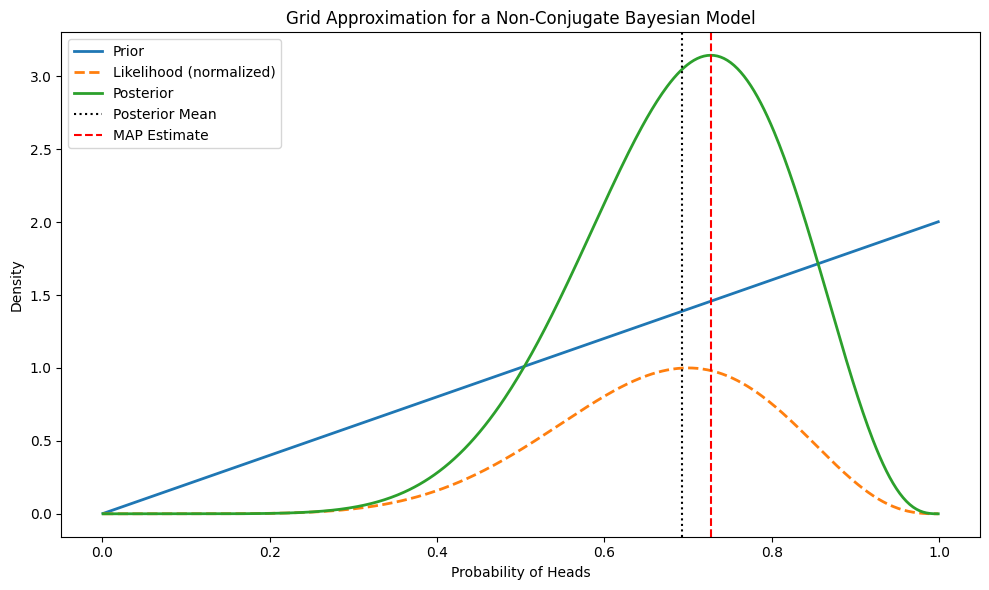

In [5]:
# Visualizing.

plt.figure(figsize=(10, 6))

plt.plot(
    theta_grid,
    prior,
    label="Prior",
    linewidth=2
)

plt.plot(
    theta_grid,
    likelihood / likelihood.max(),
    "--",
    label="Likelihood (normalized)",
    linewidth=2
)

plt.plot(
    theta_grid,
    posterior,
    label="Posterior",
    linewidth=2
)

plt.axvline(
    posterior_mean,
    color="black",
    linestyle=":",
    label="Posterior Mean"
)

plt.axvline(
    map_estimate,
    color="red",
    linestyle="--",
    label="MAP Estimate"
)

plt.title("Grid Approximation for a Non-Conjugate Bayesian Model")
plt.xlabel("Probability of Heads")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

#### Monte Carlo

In [6]:
# Defining the observed data.

n = 10
heads = 7

print("Number of trials: ", n)
print("Number of heads: ", heads)

# Defining the proposal distribution.

proposal_alpha = 2
proposal_beta = 2

# Drawing samples from the proposal distribution.

n_samples = 10000

theta_samples = np.random.beta(
    proposal_alpha,
    proposal_beta,
    size=n_samples
)

Number of trials:  10
Number of heads:  7


In [7]:
# Computing the prior.
# Prior: p(θ) ∝ θ

prior = theta_samples

# Computing the likelihood.

likelihood = theta_samples**heads * (1 - theta_samples)**(n - heads)

# Computing the proposal density.

proposal_density = beta.pdf(
    theta_samples,
    proposal_alpha,
    proposal_beta
)

# Computing the importance weights.

weights = (prior * likelihood) / proposal_density

# Normalizing the weights.

weights = weights / np.sum(weights)

# Approximating the posterior mean.

posterior_mean = np.sum(weights * theta_samples)

print("Number of samples: ", n_samples)
print("Posterior mean: ", posterior_mean)

# Computing the analytical posterior mean for comparison.

true_posterior_mean = 9 / 13

print("Analytical posterior mean: ", true_posterior_mean)

Number of samples:  10000
Posterior mean:  0.6928744185570022
Analytical posterior mean:  0.6923076923076923


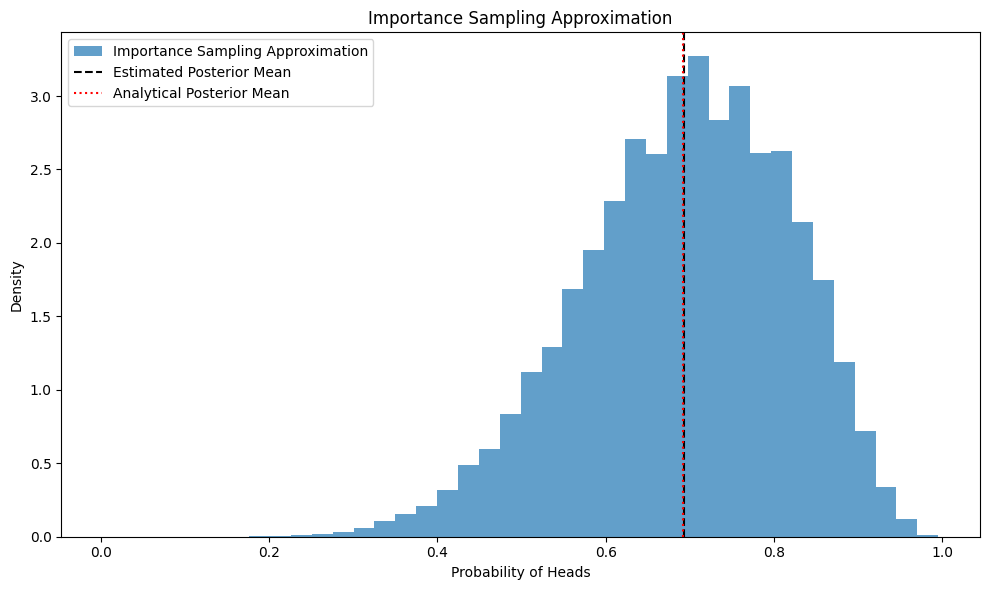

Estimated posterior mean:  0.6928744185570022
Analytical posterior mean:  0.6923076923076923
Absolute error:  0.0005667262493098679


In [8]:
# Visualizing and comparing the weighted posterior approximation.

plt.figure(figsize=(10, 6))

plt.hist(
    theta_samples,
    bins=40,
    weights=weights,
    density=True,
    alpha=0.7,
    label="Importance Sampling Approximation"
)

plt.axvline(
    posterior_mean,
    color="black",
    linestyle="--",
    label="Estimated Posterior Mean"
)

plt.axvline(
    true_posterior_mean,
    color="red",
    linestyle=":",
    label="Analytical Posterior Mean"
)

plt.title("Importance Sampling Approximation")
plt.xlabel("Probability of Heads")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

# Comparing the results.

print("Estimated posterior mean: ", posterior_mean)
print("Analytical posterior mean: ", true_posterior_mean)
print("Absolute error: ", abs(posterior_mean - true_posterior_mean))

#### Grid Approximation vs. Importance Sampling

In [9]:
# Defining the observed data.

n = 10
heads = 7

print("Number of trials: ", n)
print("Number of heads: ", heads)

Number of trials:  10
Number of heads:  7


In [10]:
# Grid Approximation

# Creating a grid of parameter values.

theta_grid = np.linspace(0.001, 0.999, 1000)

# Defining a non-conjugate prior.

prior = theta_grid

# Computing the likelihood.

likelihood = theta_grid**heads * (1 - theta_grid)**(n - heads)

# Computing the posterior.

posterior = prior * likelihood
posterior = posterior / np.trapezoid(posterior, theta_grid)

# Computing the posterior mean.

grid_mean = np.trapezoid(
    theta_grid * posterior,
    theta_grid
)

print("Posterior mean:", grid_mean)

Posterior mean: 0.6923076920118452


In [11]:
# Importance Sampling

# Defining the proposal distribution.

proposal_alpha = 2
proposal_beta = 2

# Drawing samples.

n_samples = 10000

theta_samples = np.random.beta(
    proposal_alpha,
    proposal_beta,
    size=n_samples
)

# Computing the prior.

prior_samples = theta_samples

# Computing the likelihood.

likelihood_samples = (theta_samples**heads * (1 - theta_samples)**(n - heads))

# Computing the proposal density.

proposal_density = (theta_samples**(proposal_alpha - 1) * (1 - theta_samples)**(proposal_beta - 1))

proposal_density *= (
    math.gamma(proposal_alpha + proposal_beta)
    /
    (math.gamma(proposal_alpha) * math.gamma(proposal_beta))
)

# Computing importance weights.

weights = (prior_samples * likelihood_samples / proposal_density)

weights = weights / np.sum(weights)

# Computing the posterior mean.

importance_mean = np.sum(weights * theta_samples)

print("Posterior mean:", importance_mean)

Posterior mean: 0.690920981785256


In [12]:
# Analytical Solution

true_mean = 9 / 13

print("Posterior mean: ", true_mean)

Posterior mean:  0.6923076923076923


In [13]:
# Comparing the methods

print("Grid approximation error: ", abs(grid_mean - true_mean))
print("Importance sampling error: ", abs(importance_mean - true_mean))

Grid approximation error:  2.9584712457619844e-10
Importance sampling error:  0.0013867105224363296


#### Metropolis Algorithm

In [14]:
# Defining the target distribution. Mixture of two Gaussian distributions.

def target_distribution(x):

    gaussian_1 = np.exp(-0.5 * ((x + 2) / 0.8) ** 2)

    gaussian_2 = 0.7 * np.exp(-0.5 * ((x - 2) / 0.5) ** 2)

    return gaussian_1 + gaussian_2

In [15]:
# Metropolis sampler

n_samples = 10000
proposal_std = 1.0

samples = np.zeros(n_samples)

current = 0.0
accepted = 0

# Running the Metropolis algorithm.

for i in range(n_samples):

    proposal = np.random.normal(loc=current, scale=proposal_std)

    acceptance_ratio = (target_distribution(proposal) / target_distribution(current))

    acceptance_probability = min(1, acceptance_ratio)

    if np.random.rand() < acceptance_probability:

        current = proposal
        accepted += 1

    samples[i] = current

# Computing the acceptance rate.

acceptance_rate = accepted / n_samples

print("Number of samples:", n_samples)
print("Proposal standard deviation:", proposal_std)
print("Acceptance rate:", acceptance_rate)

Number of samples: 10000
Proposal standard deviation: 1.0
Acceptance rate: 0.6099


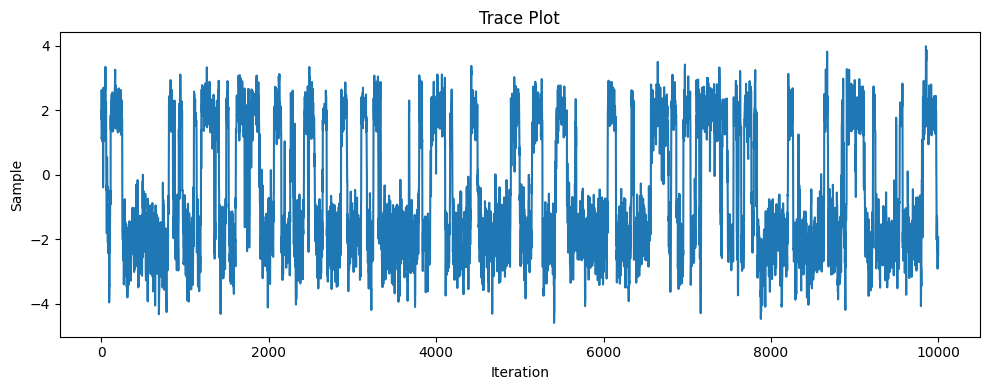

In [16]:
# Visualizing the trace.

plt.figure(figsize=(10, 4))

plt.plot(samples)

plt.xlabel("Iteration")
plt.ylabel("Sample")
plt.title("Trace Plot")

plt.tight_layout()

plt.show()

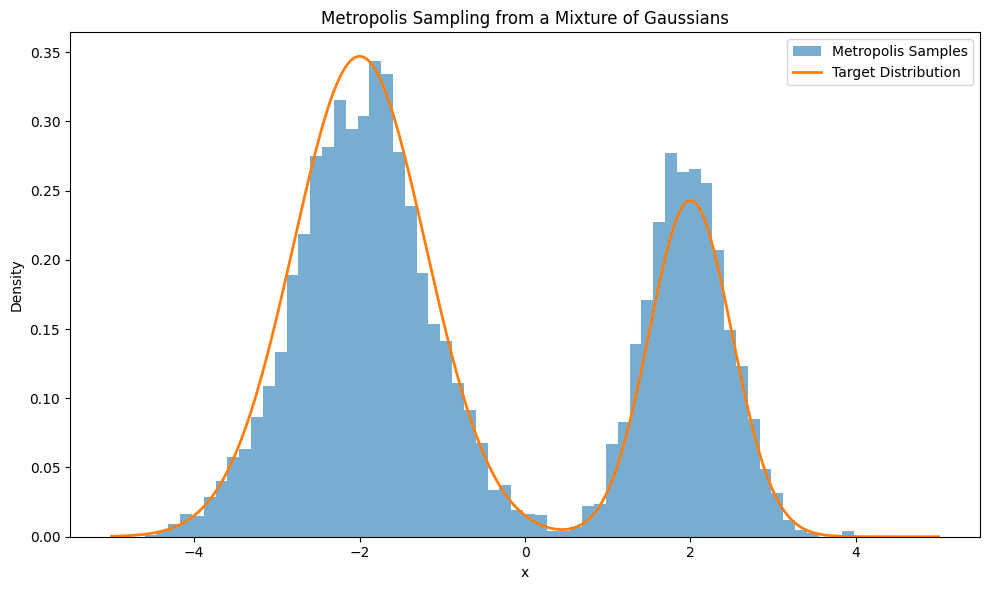

In [18]:
# Visualizing the sampled distribution.

x = np.linspace(-5, 5, 500)

target = target_distribution(x)

target /= np.trapezoid(target, x)

plt.figure(figsize=(10, 6))

plt.hist(
    samples,
    bins=60,
    density=True,
    alpha=0.6,
    label="Metropolis Samples"
)

plt.plot(
    x,
    target,
    linewidth=2,
    label="Target Distribution"
)

plt.title("Metropolis Sampling from a Mixture of Gaussians")
plt.xlabel("x")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

#### Trace

In [19]:
# Defining the target distribution.

def target_distribution(x):

    gaussian_1 = np.exp(-0.5 * ((x + 2) / 0.8) ** 2)

    gaussian_2 = 0.7 * np.exp(-0.5 * ((x - 2) / 0.5) ** 2)

    return gaussian_1 + gaussian_2

In [20]:
# Running the Metropolis sampler.

n_samples = 10000
proposal_std = 1.0

samples = np.zeros(n_samples)

current = 0.0
accepted = 0

for i in range(n_samples):

    proposal = np.random.normal(
        current,
        proposal_std
    )

    acceptance_ratio = (target_distribution(proposal) / target_distribution(current))

    acceptance_probability = min(1, acceptance_ratio)

    if np.random.rand() < acceptance_probability:

        current = proposal
        accepted += 1

    samples[i] = current

acceptance_rate = accepted / n_samples

print("Number of samples:", n_samples)
print("Acceptance rate:", acceptance_rate)

Number of samples: 10000
Acceptance rate: 0.6103


In [21]:
# Removing burn-in samples.

burn_in = 1000

posterior_samples = samples[burn_in:]

print("Burn-in:", burn_in)
print("Remaining samples:", len(posterior_samples))

Burn-in: 1000
Remaining samples: 9000


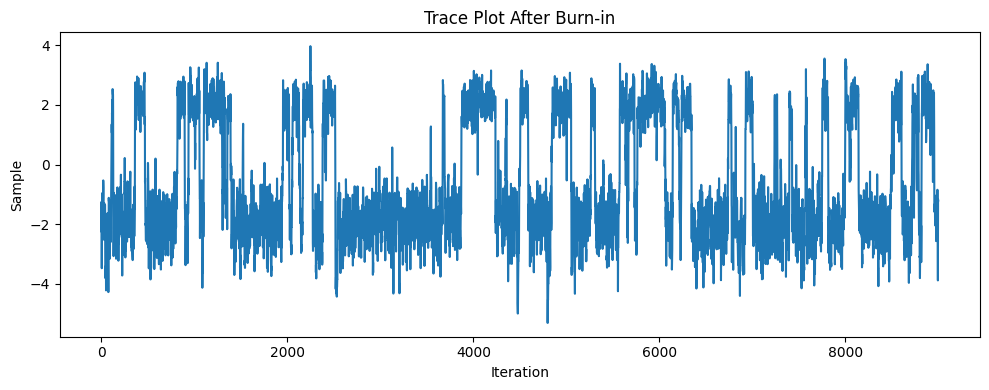

In [22]:
# Plotting the trace.

plt.figure(figsize=(10, 4))

plt.plot(posterior_samples)

plt.title("Trace Plot After Burn-in")
plt.xlabel("Iteration")
plt.ylabel("Sample")

plt.tight_layout()

plt.show()

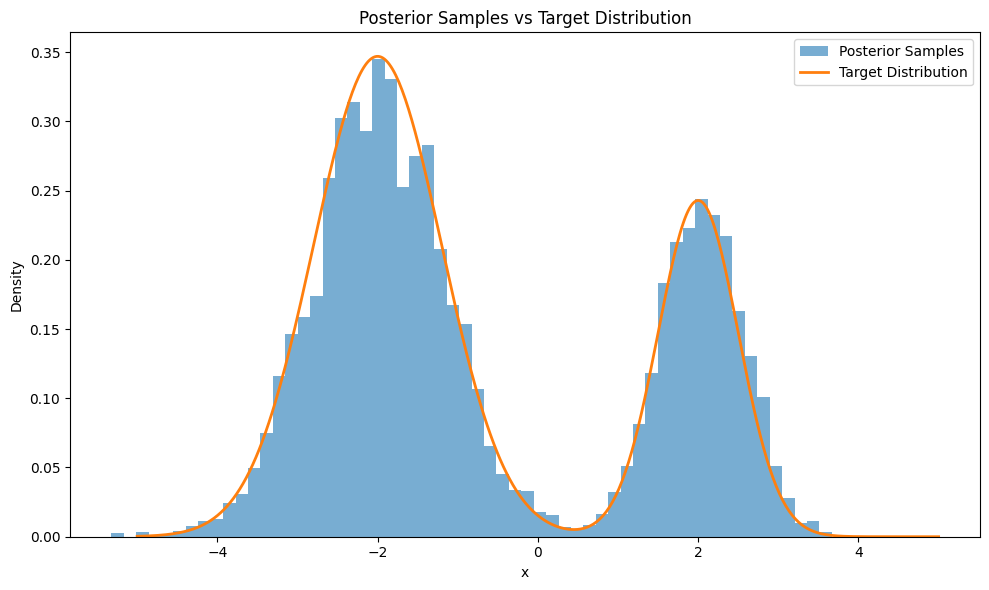

Sample mean: -0.6612698246176313
Sample standard deviation: 2.035136515476371


In [26]:
# Visualizing the target and sampled distribution.

x = np.linspace(-5, 5, 500)

target = target_distribution(x)
target /= np.trapezoid(target, x)

plt.figure(figsize=(10, 6))

plt.hist(
    posterior_samples,
    bins=60,
    density=True,
    alpha=0.6,
    label="Posterior Samples"
)

plt.plot(
    x,
    target,
    linewidth=2,
    label="Target Distribution"
)

plt.title("Posterior Samples vs Target Distribution")
plt.xlabel("x")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()

# Computing summary statistics.

print("Sample mean:", np.mean(posterior_samples))
print("Sample standard deviation:", np.std(posterior_samples))

#### Proposal Step Size

In [27]:
# Defining the target distribution.

def target_distribution(x):

    gaussian_1 = np.exp(-0.5 * ((x + 2) / 0.8) ** 2)

    gaussian_2 = 0.7 * np.exp(-0.5 * ((x - 2) / 0.5) ** 2)

    return gaussian_1 + gaussian_2

In [28]:
# Defining the Metropolis sampler.

def metropolis_sampler(proposal_std, n_samples=5000):

    samples = np.zeros(n_samples)

    current = 0.0
    accepted = 0

    for i in range(n_samples):

        proposal = np.random.normal(
            current,
            proposal_std
        )

        acceptance_ratio = (target_distribution(proposal) / target_distribution(current))

        acceptance_probability = min(1, acceptance_ratio)

        if np.random.rand() < acceptance_probability:

            current = proposal
            accepted += 1

        samples[i] = current

    acceptance_rate = accepted / n_samples

    return samples, acceptance_rate


Proposal step size: 0.2
Acceptance rate: 0.882
Sample mean: 1.4670903531422894
Sample standard deviation: 1.501968998989603


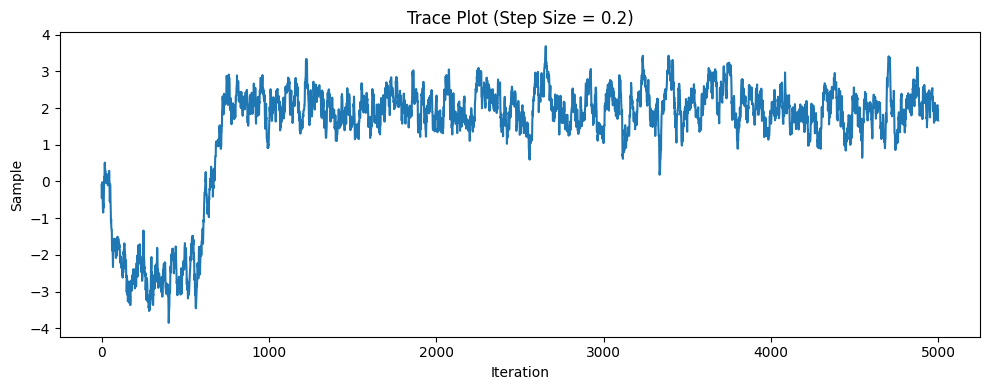


Proposal step size: 1.0
Acceptance rate: 0.6142
Sample mean: -0.6706407430978687
Sample standard deviation: 2.0181983545927142


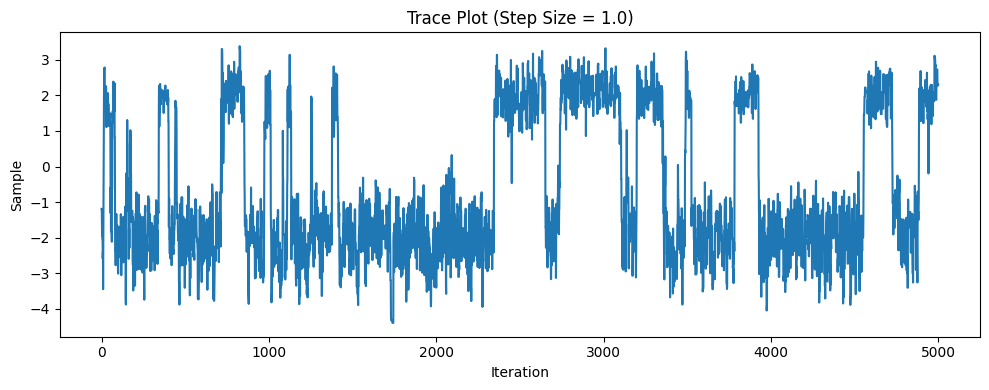


Proposal step size: 4.0
Acceptance rate: 0.326
Sample mean: -0.7892713475626318
Sample standard deviation: 1.961475665342704


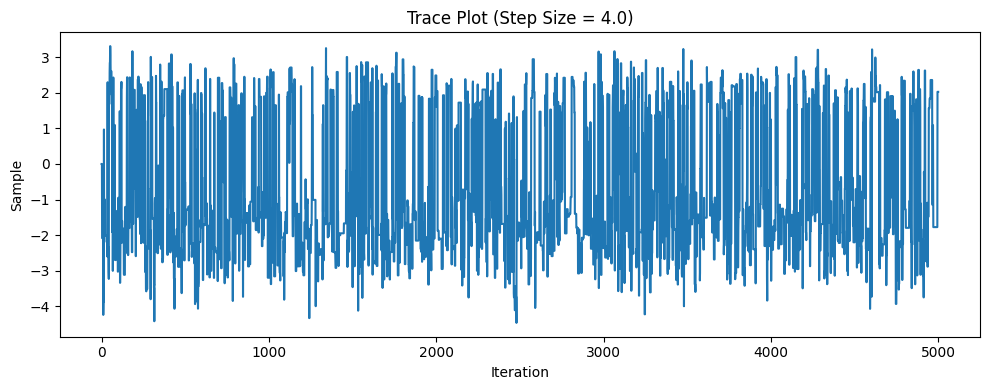

In [29]:
# Running the sampler with different proposal step sizes.

step_sizes = [0.2, 1.0, 4.0]

for step_size in step_sizes:

    samples, acceptance_rate = metropolis_sampler(step_size)

    print("\nProposal step size:", step_size)
    print("Acceptance rate:", acceptance_rate)
    print("Sample mean:", np.mean(samples))
    print("Sample standard deviation:", np.std(samples))

    plt.figure(figsize=(10, 4))

    plt.plot(samples)

    plt.title(f"Trace Plot (Step Size = {step_size})")
    plt.xlabel("Iteration")
    plt.ylabel("Sample")
    

    plt.tight_layout()
    
    plt.show()

#### Gibbs Sampling

In [32]:
# Simulating Normal data.

true_mean = 100
true_variance = 25

n = 50

data = np.random.normal(loc=true_mean, scale=np.sqrt(true_variance), size=n)

print("Sample size:", n)
print("Sample mean:", np.mean(data))
print("Sample variance:", np.var(data, ddof=1))

Sample size: 50
Sample mean: 100.77824036787965
Sample variance: 27.985926897095354


In [33]:
# Defining prior parameters.

mu0 = 95
tau0_squared = 100

alpha0 = 2
beta0 = 20

In [34]:
# Gibbs sampler settings.

n_samples = 5000

mu_samples = np.zeros(n_samples)
variance_samples = np.zeros(n_samples)

# Initial values.

current_mu = np.mean(data)
current_variance = np.var(data, ddof=1)

In [35]:
# Running the Gibbs sampler.

for i in range(n_samples):

    # Sampling the mean given the variance.

    posterior_variance = 1 / ((1 / tau0_squared) + (n / current_variance))

    posterior_mean = posterior_variance * ((mu0 / tau0_squared) + (n * np.mean(data) / current_variance))

    current_mu = np.random.normal(
        posterior_mean,
        np.sqrt(posterior_variance)
    )

    # Sampling the variance given the mean.

    alpha_post = alpha0 + n / 2

    beta_post = beta0 + 0.5 * np.sum(
        (data - current_mu) ** 2
    )

    current_variance = invgamma.rvs(
        a=alpha_post,
        scale=beta_post
    )

    # Storing samples.

    mu_samples[i] = current_mu
    variance_samples[i] = current_variance

In [37]:
# Removing burn-in.

burn_in = 1000

mu_samples = mu_samples[burn_in:]
variance_samples = variance_samples[burn_in:]

# Posterior summaries.

print("Posterior Mean:", np.mean(mu_samples))
print("Posterior Variance:", np.mean(variance_samples))

Posterior Mean: 100.7423393717744
Posterior Variance: 27.49132514256383


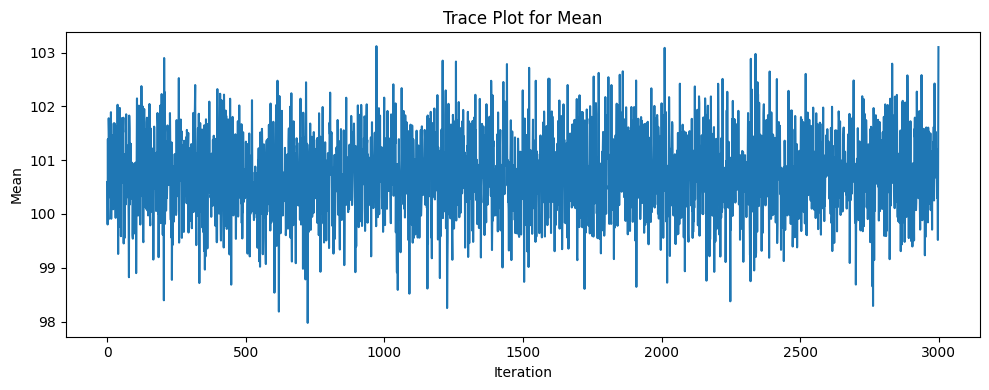

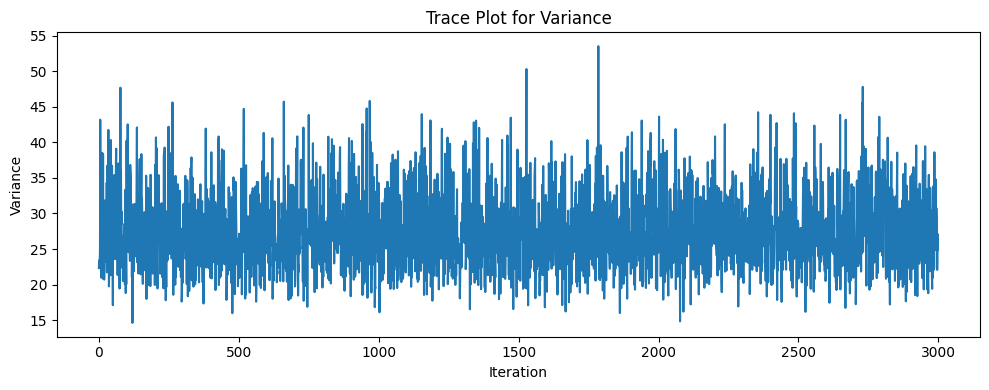

In [38]:
# Visualizing trace plots.

plt.figure(figsize=(10,4))

plt.plot(mu_samples)

plt.title("Trace Plot for Mean")
plt.xlabel("Iteration")
plt.ylabel("Mean")

plt.tight_layout()

plt.show()

plt.figure(figsize=(10,4))

plt.plot(variance_samples)

plt.title("Trace Plot for Variance")
plt.xlabel("Iteration")
plt.ylabel("Variance")

plt.tight_layout()

plt.show()

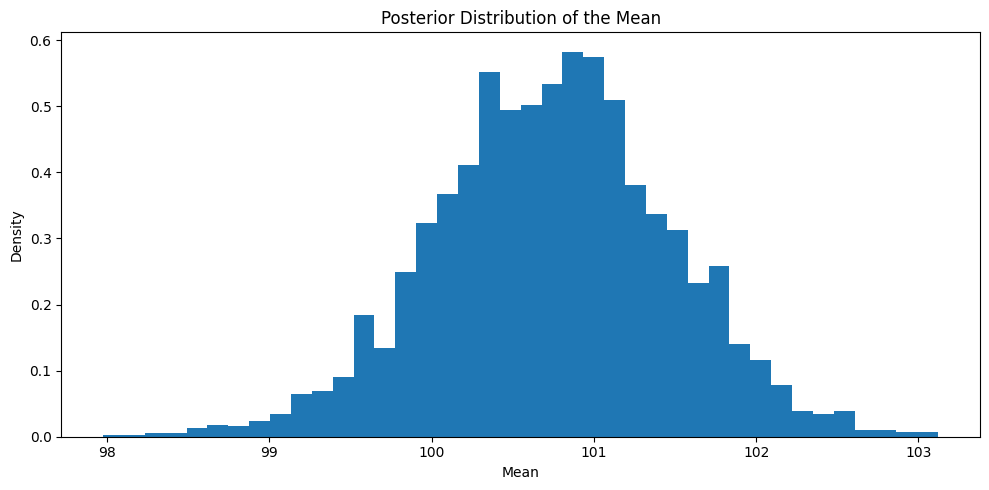

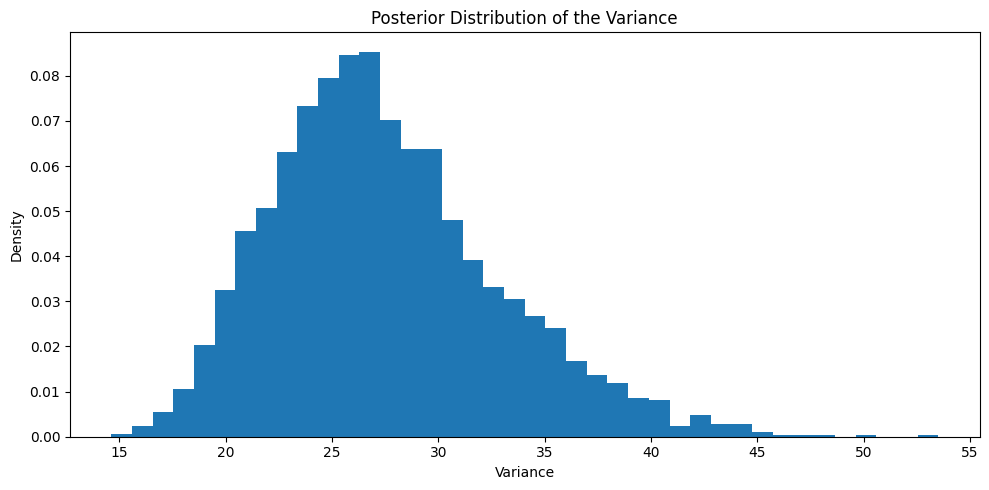

In [39]:
# Visualizing posterior distributions.

plt.figure(figsize=(10,5))

plt.hist(
    mu_samples,
    bins=40,
    density=True
)

plt.title("Posterior Distribution of the Mean")
plt.xlabel("Mean")
plt.ylabel("Density")

plt.tight_layout()

plt.show()

plt.figure(figsize=(10,5))

plt.hist(
    variance_samples,
    bins=40,
    density=True
)

plt.title("Posterior Distribution of the Variance")
plt.xlabel("Variance")
plt.ylabel("Density")

plt.tight_layout()

plt.show()

#### Multiple Chains and Gelman–Rubin Statistic (R-hat)

In [40]:
# Simulating Normal data.

true_mean = 100
true_variance = 25

n = 50

data = np.random.normal(loc=true_mean, scale=np.sqrt(true_variance), size=n)

print("Sample size:", n)
print("Sample mean:", np.mean(data))

# Defining prior parameters.

mu0 = 95
tau0_squared = 100

alpha0 = 2
beta0 = 20

Sample size: 50
Sample mean: 100.71363465991122


In [43]:
# Gibbs sampler.

def gibbs_sampler(initial_mu, initial_variance, n_samples):

    mu_samples = np.zeros(n_samples)
    variance_samples = np.zeros(n_samples)

    current_mu = initial_mu
    current_variance = initial_variance

    for i in range(n_samples):

        posterior_variance = 1 / ((1 / tau0_squared) + (n / current_variance))

        posterior_mean = posterior_variance * ((mu0 / tau0_squared) + (n * np.mean(data) / current_variance))

        current_mu = np.random.normal(
            posterior_mean,
            np.sqrt(posterior_variance)
        )

        alpha_post = alpha0 + n / 2

        beta_post = beta0 + 0.5 * np.sum(
            (data - current_mu) ** 2
        )

        current_variance = invgamma.rvs(
            a=alpha_post,
            scale=beta_post
        )

        mu_samples[i] = current_mu
        variance_samples[i] = current_variance

    return mu_samples, variance_samples

In [46]:
# Running multiple chains.

n_samples = 5000

chain_1, _ = gibbs_sampler(80, 10, n_samples)
chain_2, _ = gibbs_sampler(100, 25, n_samples)
chain_3, _ = gibbs_sampler(120, 40, n_samples)
chain_4, _ = gibbs_sampler(140, 60, n_samples)

burn_in = 1000

chains = np.array([
    chain_1[burn_in:],
    chain_2[burn_in:],
    chain_3[burn_in:],
    chain_4[burn_in:]
])

print("Number of chains:", chains.shape[0])
print("Samples per chain:", chains.shape[1])

Number of chains: 4
Samples per chain: 4000


In [52]:
# Computing R-hat.

idata = az.convert_to_dataset({"mu": chains})

rhat = az.rhat(idata)

print()
print("R-hat: ", rhat)


R-hat:  <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    mu       float64 8B 0.9999


#### Autocorrelation, Effective Sample Size (ESS), and Diagnostic Visuals

In [55]:
# Simulating Normal data.

true_mean = 100
true_variance = 25

n = 50

data = np.random.normal(loc=true_mean, scale=np.sqrt(true_variance), size=n)

# Defining prior parameters.

mu0 = 95
tau0_squared = 100

alpha0 = 2
beta0 = 20

In [57]:
# Gibbs sampler

def gibbs_sampler(initial_mu, initial_variance, n_samples):

    mu_samples = np.zeros(n_samples)

    current_mu = initial_mu
    current_variance = initial_variance

    for i in range(n_samples):

        posterior_variance = 1 / ((1 / tau0_squared) + (n / current_variance))

        posterior_mean = posterior_variance * ((mu0 / tau0_squared) + (n * np.mean(data) / current_variance))

        current_mu = np.random.normal(
            posterior_mean,
            np.sqrt(posterior_variance)
        )

        alpha_post = alpha0 + n / 2

        beta_post = beta0 + 0.5 * np.sum(
            (data - current_mu) ** 2
        )

        current_variance = invgamma.rvs(
            a=alpha_post,
            scale=beta_post
        )

        mu_samples[i] = current_mu

    return mu_samples

In [58]:
# Running multiple chains.

n_samples = 5000
burn_in = 1000

chain_1 = gibbs_sampler(80, 10, n_samples)[burn_in:]
chain_2 = gibbs_sampler(100, 25, n_samples)[burn_in:]
chain_3 = gibbs_sampler(120, 40, n_samples)[burn_in:]
chain_4 = gibbs_sampler(140, 60, n_samples)[burn_in:]

chains = np.array([
    chain_1,
    chain_2,
    chain_3,
    chain_4
])

print("Number of chains:", chains.shape[0])
print("Samples per chain:", chains.shape[1])

Number of chains: 4
Samples per chain: 4000



Effective Sample Size (ESS):  16267.292426427215

First 10 autocorrelation values:  [ 1.         -0.00936094  0.01147473 -0.02857975  0.00408763 -0.03394477
  0.02630204  0.00310394  0.01681894  0.01550664]


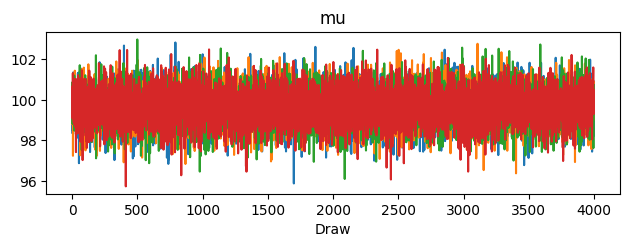

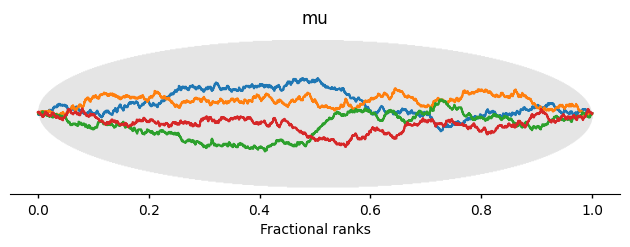

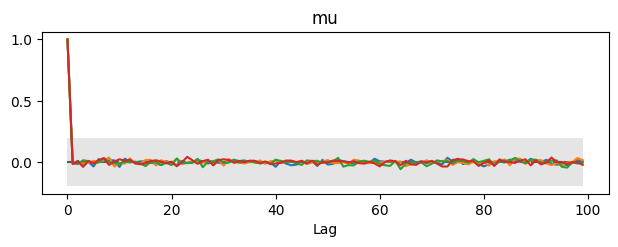

In [65]:
# Creating an ArviZ InferenceData object.

idata = az.convert_to_dataset({"mu": chains})

# Computing Effective Sample Size.

ess = az.ess(idata)

print("\nEffective Sample Size (ESS): ", float(ess.mu))

# Computing Autocorrelation.

autocorrelation = np.correlate(
    chain_1 - np.mean(chain_1),
    chain_1 - np.mean(chain_1),
    mode="full"
)

autocorrelation = autocorrelation[autocorrelation.size // 2:]
autocorrelation /= autocorrelation[0]

print("\nFirst 10 autocorrelation values: ", autocorrelation[:10])


# Trace plot

az.plot_trace(idata)

plt.tight_layout()

plt.show()

# Rank plot

az.plot_rank(idata)

plt.tight_layout()

plt.show()

# Autocorrelation plot.

az.plot_autocorr(idata)

plt.tight_layout()

plt.show()

#### Bayesian Logistic Regression with PyMC

In [2]:
# Simulating binary data.

n = 100

x = np.random.normal(size=n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations:", n)
print("Number of successes:", np.sum(y))

Number of observations: 100
Number of successes: 39


In [5]:
# Building the Bayesian logistic regression model.

with pm.Model() as logistic_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    logits = intercept + slope * x

    p = pm.math.sigmoid(logits)

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.



Posterior Summary
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.605  0.273  -1.093   -0.069      0.003    0.003    7241.0   
slope      2.011  0.399   1.269    2.768      0.005    0.004    6964.0   

           ess_tail  r_hat  
intercept    5915.0    1.0  
slope        5637.0    1.0  


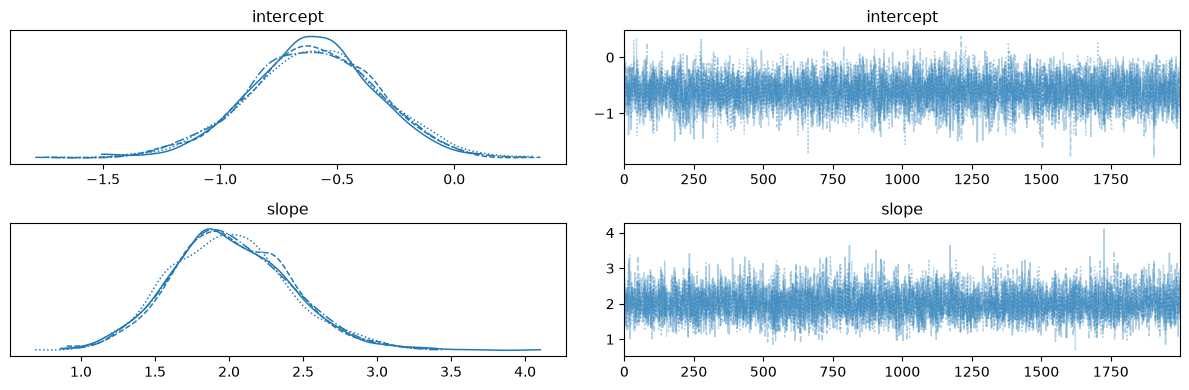

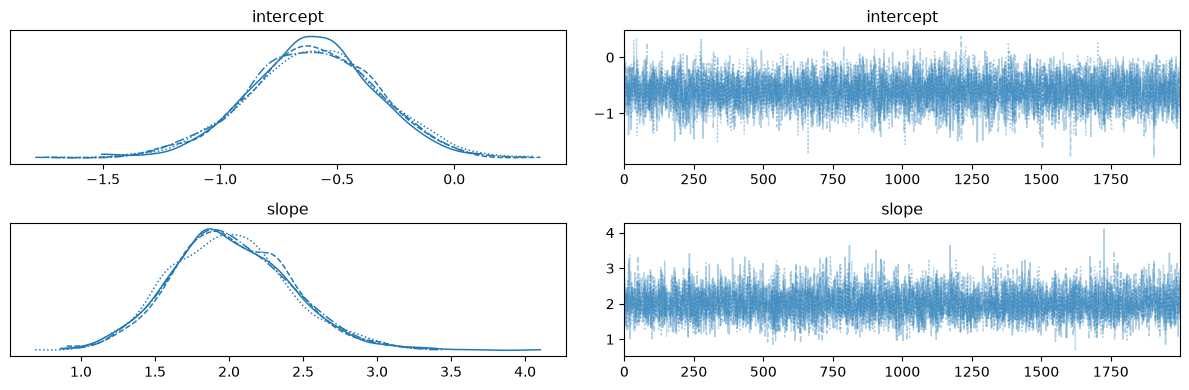

In [6]:
# Posterior summary

summary = az.summary(trace)

print("\nPosterior Summary")
print(summary)

# Trace plots

az.plot_trace(trace)

plt.tight_layout()

plt.show()

# Posterior distributions.

az.plot_trace(trace)

plt.tight_layout()

plt.show()

#### Compare NUTS and Metropolis

In [7]:
# Simulating binary data.

n = 100

x = np.random.normal(size=n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

print("Number of observations:", n)
print("Number of successes:", np.sum(y))

Number of observations: 100
Number of successes: 47


In [8]:
# Bayesian logistic regression.

with pm.Model() as logistic_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    logits = intercept + slope * x

    p = pm.math.sigmoid(logits)

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

    # Sampling with NUTS.

    trace_nuts = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

    # Sampling with Metropolis.

    trace_metropolis = pm.sample(
        draws=2000,
        tune=1000,
        step=pm.Metropolis(),
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [intercept]
>Metropolis: [slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


NUTS Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.115  0.254  -0.611    0.347      0.003    0.003    7882.0   
slope      1.868  0.384   1.167    2.596      0.004    0.005    7731.0   

           ess_tail  r_hat  
intercept    5788.0    1.0  
slope        5006.0    1.0  

Metropolis Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.117  0.255  -0.578    0.379      0.006    0.005    1564.0   
slope      1.864  0.381   1.127    2.552      0.010    0.007    1471.0   

           ess_tail  r_hat  
intercept    1680.0    1.0  
slope        1544.0    1.0  

Intercept (NUTS):  -0.115
Intercept (Metropolis):  -0.117

Slope (NUTS):  1.868
Slope (Metropolis):  1.864


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'slope'}>]], dtype=object)

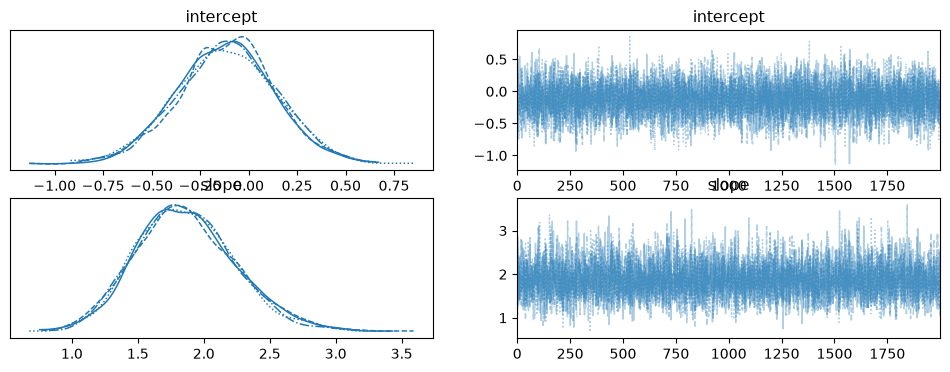

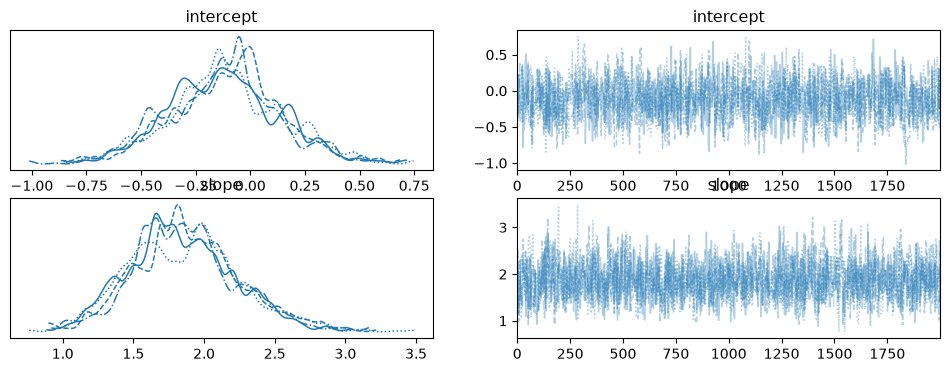

In [9]:
# Posterior summaries

print("NUTS Summary\n", az.summary(trace_nuts))
print("\nMetropolis Summary\n", az.summary(trace_metropolis))

# Comparing posterior means.

nuts_summary = az.summary(trace_nuts)
metro_summary = az.summary(trace_metropolis)

print("\nIntercept (NUTS): ", nuts_summary.loc["intercept", "mean"])
print("Intercept (Metropolis): ", metro_summary.loc["intercept", "mean"])

print("\nSlope (NUTS): ", nuts_summary.loc["slope", "mean"])
print("Slope (Metropolis): ", metro_summary.loc["slope", "mean"])

# Trace plots.

az.plot_trace(trace_nuts)

az.plot_trace(trace_metropolis)

#### ArviZ Summary (Mean and HPD Intervals)

In [10]:
# Simulating binary data.

n = 100

x = np.random.normal(size=n)

true_intercept = -0.5
true_slope = 2.0

logits = true_intercept + true_slope * x

probability = 1 / (1 + np.exp(-logits))

y = np.random.binomial(
    n=1,
    p=probability,
    size=n
)

In [11]:
# Building the Bayesian logistic regression model.

with pm.Model() as logistic_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=5
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=5
    )

    logits = intercept + slope * x

    p = pm.math.sigmoid(logits)

    outcome = pm.Bernoulli(
        "outcome",
        p=p,
        observed=y
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
intercept -0.749  0.272    -1.289     -0.222      0.004    0.003    5917.0   
slope      1.745  0.359     1.075      2.447      0.005    0.004    5871.0   

           ess_tail  r_hat  
intercept    5486.0    1.0  
slope        5551.0    1.0  

Intercept: -0.749
Slope: 1.745
Intercept: [ -1.289 , -0.222 ]
Slope: [ 1.075 , 2.447 ]


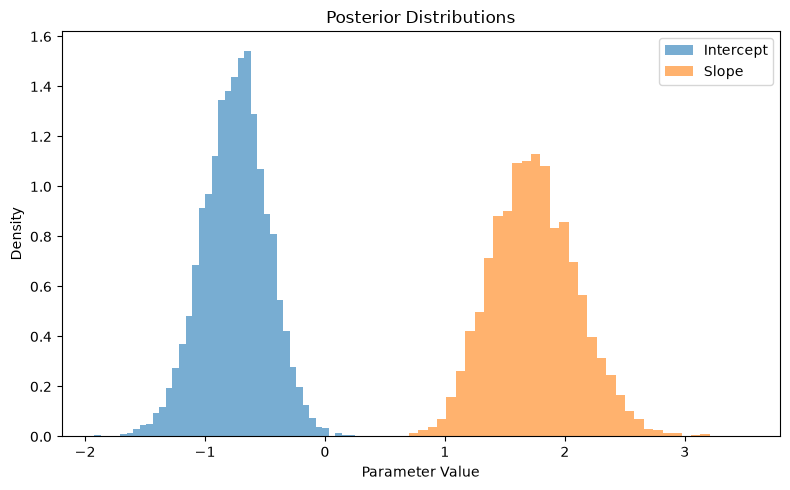

In [12]:
# Posterior summary

summary = az.summary(trace, hdi_prob=0.95)

print(summary)

# Posterior means

print("\nIntercept:", summary.loc["intercept", "mean"])
print("Slope:", summary.loc["slope", "mean"])

# 95% ETI

print(
    "Intercept:",
    "[",
    summary.loc["intercept", "hdi_2.5%"],
    ",",
    summary.loc["intercept", "hdi_97.5%"],
    "]"
)

print(
    "Slope:",
    "[",
    summary.loc["slope", "hdi_2.5%"],
    ",",
    summary.loc["slope", "hdi_97.5%"],
    "]"
)

# Posterior distributions

intercept_samples = trace.posterior["intercept"].values.flatten()
slope_samples = trace.posterior["slope"].values.flatten()

plt.figure(figsize=(8,5))

plt.hist(
    intercept_samples,
    bins=40,
    density=True,
    alpha=0.6,
    label="Intercept"
)

plt.hist(
    slope_samples,
    bins=40,
    density=True,
    alpha=0.6,
    label="Slope"
)

plt.title("Posterior Distributions")
plt.xlabel("Parameter Value")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.show()